# LBF Robust Algorithm Comparison

Compares DeepSRQ with the `path_mcp_nplayer_pool` stage-game solver against `dsr_fp` and `sr_adidas` on the same three Level-Based Foraging scenarios used by the EPyMARL baseline notebook. Running all algorithm cells produces 3 algorithms x 3 scenarios = 9 runs.


In [1]:
from pathlib import Path
import sys
import time
import traceback

import numpy as np

ROOT = Path.cwd()
if ROOT.name == "lbf_grid":
    REPO_ROOT = ROOT.parents[1]
elif (ROOT / "discrete_action_space" / "lbf_grid").exists():
    REPO_ROOT = ROOT
else:
    REPO_ROOT = ROOT.parents[1]

for path in [
    REPO_ROOT,
    REPO_ROOT / "discrete_action_space",
    REPO_ROOT / "discrete_action_space" / "bimatrix_game",
    REPO_ROOT / "discrete_action_space" / "lbf_grid",
]:
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))

from bimatrix_game.stats_utils import plot_training_stats, save_training_stats
from discrete_action_space.lbf_grid import pz_wrapper as _lbf_pz_wrapper
from discrete_action_space.lbf_grid import scenarios as _lbf_scenarios

# Some legacy LBF trainers import these notebook-style module names.
sys.modules.setdefault("pz_wrapper", _lbf_pz_wrapper)
sys.modules.setdefault("scenarios", _lbf_scenarios)

from discrete_action_space.dsr_fp.lbf_grid.dsr_fp_lbf import train_lbf_dsr_fp_experiment
from discrete_action_space.lbf_grid.deep_srq_lbf import train_lbf_deep_srq_experiment
from discrete_action_space.lbf_grid.epymarl_lbf_env import EPYMARL_LBF_SCENARIOS
from discrete_action_space.lbf_grid.pz_wrapper import make_pz_env
from discrete_action_space.sr_adidas.train import train_sr_adidas

OUTPUT_ROOT = REPO_ROOT / "discrete_action_space" / "lbf_grid" / "ablation_runs" / "nplayer_solver_ablation"
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)
OUTPUT_ROOT


PosixPath('/home/wowthecoder/SRE-DQN/discrete_action_space/lbf_grid/ablation_runs/nplayer_solver_ablation')

In [2]:
# Smoke defaults. Increase N_EPISODES for a full run.
N_EPISODES = 3000
USE_GPU = True
ROBUST_EPSILON_START = 0.5
EPSILON_SCHEDULE = "linear"
BASE_SEED = 2025


def _epymarl_scenario_to_lbf_config(scenario):
    config = dict(scenario.kwargs)
    config["max_food"] = int(config.pop("max_num_food"))
    config["field_size"] = tuple(config["field_size"])
    return config


SCENARIOS = tuple(
    {
        "key": scenario.key,
        "name": scenario.description,
        "gym_id": scenario.gym_id,
        "time_limit": int(scenario.time_limit),
        "config": _epymarl_scenario_to_lbf_config(scenario),
    }
    for scenario in EPYMARL_LBF_SCENARIOS.values()
)

COMMON_HP = {
    "batch_size": 16,
    "learning_starts": 100,
    "replay_buffer_capacity": 5000,
    "sre_num_repeats": 8,
    "sre_solver_workers": 8,
    "solver_max_iter": 100,
    "solver_tol": 1e-4,
}

DSR_FP_HP = {
    "batch_size": COMMON_HP["batch_size"],
    "learning_starts": COMMON_HP["learning_starts"],
    "replay_buffer_capacity": COMMON_HP["replay_buffer_capacity"],
    "br_n_iter": 20,
}

SR_ADIDAS_HP = {
    "batch_size": COMMON_HP["batch_size"],
    "learning_starts": COMMON_HP["learning_starts"],
    "buffer_size": COMMON_HP["replay_buffer_capacity"],
    "lr_q": 3e-4,
    "lr_pi": 1e-3,
    "eval_interval": 100,
}


VARIANTS = (
    {"label": "path_mcp_nplayer_pool", "algorithm": "deep_srq", "solver_name": "path_mcp_nplayer_pool"},
    {"label": "dsr_fp", "algorithm": "dsr_fp"},
    {"label": "sr_adidas", "algorithm": "sr_adidas"},
)

print(f"Configured {len(SCENARIOS)} scenarios x {len(VARIANTS)} algorithms = {len(SCENARIOS) * len(VARIANTS)} runs")
for scenario in SCENARIOS:
    print(f"- {scenario['key']}: {scenario['name']}")


Configured 3 scenarios x 4 algorithms = 12 runs
- lbf_8x8_2p_2f_levels12: 2 agents with levels 1 and 2, 8x8 grid, 2 foods, max food level 3, full sight, 50-step episodes
- lbf_8x8_2p_2f_force_coop: 2 level-1 agents, 8x8 grid, 2 level-2 foods, full sight, forced cooperation, 50-step episodes
- lbf_10x10_3p_8f_levels123: 3 agents with levels 1, 2, and 3, 10x10 grid, 8 foods including one level-6 food, full sight, 100-step episodes


In [3]:
def _central_state(obs_dict, agent_order):
    return np.concatenate([np.asarray(obs_dict[a], dtype=np.float32).reshape(-1) for a in agent_order])


class LbfJointEnvWrapper:
    """Small adapter for trainers that expect reset() -> joint_obs and step(list) -> tuple."""

    def __init__(self, env_config, seed=None):
        self.env_config = dict(env_config)
        self.seed = seed
        self.env = make_pz_env(**self.env_config)
        self.agent_order = None
        self.reset_count = 0

    def reset(self):
        seed = None if self.seed is None else int(self.seed) + self.reset_count
        obs_dict, _ = self.env.reset(seed=seed)
        self.reset_count += 1
        self.agent_order = list(self.env.possible_agents)
        return _central_state(obs_dict, self.agent_order)

    def step(self, actions):
        action_dict = {agent: int(actions[i]) for i, agent in enumerate(self.agent_order)}
        obs_dict, reward_dict, term_dict, trunc_dict, info = self.env.step(action_dict)
        next_obs = _central_state(obs_dict, self.agent_order)
        rewards = [float(reward_dict.get(agent, 0.0)) for agent in self.agent_order]
        done = all(
            bool(term_dict.get(agent, False)) or bool(trunc_dict.get(agent, False))
            for agent in self.agent_order
        )
        return next_obs, rewards, done, info

    def close(self):
        self.env.close()



def _probe_lbf(env_config, seed=BASE_SEED):
    env = make_pz_env(**env_config)
    obs_dict, _ = env.reset(seed=seed)
    agent_order = list(env.possible_agents)
    obs_dim = int(_central_state(obs_dict, agent_order).shape[0])
    num_agents = len(agent_order)
    num_actions = int(env.action_space(agent_order[0]).n)
    env.close()
    return obs_dim, num_agents, num_actions


def _joint_rewards(stats):
    rewards = np.asarray(stats.get("rewards", []), dtype=float)
    if rewards.size == 0:
        return np.asarray([], dtype=float)
    return np.sum(rewards, axis=0)


def _wall_clock_seconds(stats):
    timing = stats.get("timing", {})
    return timing.get("wall_clock_seconds", stats.get("wall_clock_seconds", stats.get("wall_seconds")))


def _sre_timing(stats):
    timing = stats.get("timing", {})
    if "sre_solve_time" in timing:
        return timing["sre_solve_time"]
    return stats.get("sre_timing", {})


def _run_key(scenario, variant):
    return f"{scenario['key']}__{variant['label']}"


def _scenario_output_root(scenario, variant):
    return OUTPUT_ROOT / scenario["key"] / variant["label"]


def _stamp_scenario_metadata(stats, *, scenario, variant, seed):
    stats["scenario_key"] = scenario["key"]
    stats["scenario_name"] = scenario["name"]
    stats["gym_id"] = scenario["gym_id"]
    stats["time_limit"] = int(scenario["time_limit"])
    stats["lbf_config"] = dict(scenario["config"])
    stats["ablation_variant"] = variant["label"]
    stats["run_key"] = _run_key(scenario, variant)
    stats["seed"] = int(seed)
    return stats


def _write_stats_artifacts(stats):
    run_dir = Path(stats["artifact_dir"])
    run_dir.mkdir(parents=True, exist_ok=True)
    stats_path = Path(stats.get("stats_path", run_dir / "training_stats.txt"))
    plot_path = run_dir / "training_plot.png"
    plot_training_stats(stats, out_path=plot_path)
    stats["plot_path"] = str(plot_path)
    stats["stats_path"] = str(stats_path)
    save_training_stats(stats_path, stats)
    return stats


def _failure_stats(*, scenario, variant, seed, exc):
    run_dir = _scenario_output_root(scenario, variant)
    run_dir.mkdir(parents=True, exist_ok=True)
    stats = {
        "environment": "lbf_grid",
        "algorithm": variant["algorithm"],
        "status": "failed",
        "error_type": type(exc).__name__,
        "error_message": str(exc),
        "traceback": traceback.format_exc(),
        "rewards": [],
        "n_episodes": 0,
        "artifact_dir": str(run_dir),
        "stats_path": str(run_dir / "training_stats.txt"),
    }
    _stamp_scenario_metadata(stats, scenario=scenario, variant=variant, seed=seed)
    save_training_stats(stats["stats_path"], stats)
    return stats


def _normalize_sr_adidas_stats(raw, *, variant, scenario, seed, env_config, obs_dim, num_agents, num_actions, run_dir, elapsed):
    stats = {
        "environment": "lbf_grid",
        "algorithm": "sr_adidas",
        "rewards": np.asarray(raw["episode_rewards"], dtype=float).T.tolist(),
        "n_episodes": len(raw["episode_rewards"]),
        "epsilon_robust_initial": ROBUST_EPSILON_START,
        "epsilon_schedule": EPSILON_SCHEDULE,
        "lbf_config": env_config,
        "num_agents": int(num_agents),
        "num_actions": int(num_actions),
        "obs_dim": int(obs_dim),
        "agent_labels": [f"Agent {i + 1} (SR-ADIDAS)" for i in range(num_agents)],
        "artifact_dir": str(run_dir),
        "wall_clock_seconds": float(elapsed),
        "train_losses_q": raw.get("train_losses_q", []),
        "train_losses_pi": raw.get("train_losses_pi", []),
        "adi_estimates": raw.get("adi_estimates", []),
    }
    _stamp_scenario_metadata(stats, scenario=scenario, variant=variant, seed=seed)
    return _write_stats_artifacts(stats)


def run_deep_srq_variant(variant, scenario, seed):
    solver_name = variant["solver_name"]
    stats = train_lbf_deep_srq_experiment(
        n_episodes=N_EPISODES,
        solver_name=solver_name,
        epsilon_robust_initial=ROBUST_EPSILON_START,
        epsilon_schedule=EPSILON_SCHEDULE,
        seed=seed,
        output_root=_scenario_output_root(scenario, variant),
        lbf_config_overrides=scenario["config"],
        hyperparameter_overrides=COMMON_HP,
        use_gpu=USE_GPU,
        write_plots=False,
        run_name_suffix=_run_key(scenario, variant),
        print_full_stats=False,
    )
    stats["algorithm"] = "deep_srq"
    _stamp_scenario_metadata(stats, scenario=scenario, variant=variant, seed=seed)
    return _write_stats_artifacts(stats)


def run_dsr_fp_variant(variant, scenario, seed):
    stats = train_lbf_dsr_fp_experiment(
        n_episodes=N_EPISODES,
        epsilon_robust_initial=ROBUST_EPSILON_START,
        epsilon_schedule=EPSILON_SCHEDULE,
        seed=seed,
        output_root=_scenario_output_root(scenario, variant),
        lbf_config_overrides=scenario["config"],
        hyperparameter_overrides=DSR_FP_HP,
        use_gpu=USE_GPU,
        write_plots=False,
        run_name_suffix=_run_key(scenario, variant),
        print_full_stats=False,
    )
    _stamp_scenario_metadata(stats, scenario=scenario, variant=variant, seed=seed)
    return _write_stats_artifacts(stats)


def run_sr_adidas_variant(variant, scenario, seed):
    env_config = dict(scenario["config"])
    obs_dim, num_agents, num_actions = _probe_lbf(env_config, seed)
    run_dir = _scenario_output_root(scenario, variant)
    run_dir.mkdir(parents=True, exist_ok=True)

    def env_factory():
        return LbfJointEnvWrapper(env_config, seed=seed)

    start = time.perf_counter()
    raw = train_sr_adidas(
        env_factory=env_factory,
        obs_dim=obs_dim,
        num_agents=num_agents,
        num_actions=num_actions,
        n_episodes=N_EPISODES,
        max_steps_per_episode=int(env_config["max_episode_steps"]),
        seed=seed,
        epsilon_robust=ROBUST_EPSILON_START,
        epsilon_robust_end=0.0 if EPSILON_SCHEDULE == "linear" else ROBUST_EPSILON_START,
        use_gpu=USE_GPU,
        verbose=True,
        **SR_ADIDAS_HP,
    )
    elapsed = time.perf_counter() - start
    if hasattr(raw.get("agent"), "close"):
        raw["agent"].close()
    return _normalize_sr_adidas_stats(
        raw,
        variant=variant,
        scenario=scenario,
        seed=seed,
        env_config=env_config,
        obs_dim=obs_dim,
        num_agents=num_agents,
        num_actions=num_actions,
        run_dir=run_dir,
        elapsed=elapsed,
    )



RUNNERS = {
    "deep_srq": run_deep_srq_variant,
    "dsr_fp": run_dsr_fp_variant,
    "sr_adidas": run_sr_adidas_variant,
}


In [4]:
results = {}


def run_variant_on_scenario(label, scenario_key):
    variant = next(item for item in VARIANTS if item["label"] == label)
    scenario = next(item for item in SCENARIOS if item["key"] == scenario_key)
    variant_idx = list(VARIANTS).index(variant)
    scenario_idx = list(SCENARIOS).index(scenario)
    seed = BASE_SEED + scenario_idx * len(VARIANTS) + variant_idx
    key = _run_key(scenario, variant)
    print()
    print(f"=== Running {key} ===")
    try:
        stats = RUNNERS[variant["algorithm"]](variant, scenario, seed)
    except Exception as exc:
        stats = _failure_stats(scenario=scenario, variant=variant, seed=seed, exc=exc)
        print(f"FAILED {key}: {type(exc).__name__}: {exc}")
    results[key] = stats
    if stats.get("status") == "skipped":
        print(f"Skipped {key}: {stats['skip_reason']}")
    save_training_stats(OUTPUT_ROOT / "manifest.txt", results)
    return stats


def run_algorithm(label):
    return {
        scenario["key"]: run_variant_on_scenario(label, scenario["key"])
        for scenario in SCENARIOS
    }


def run_all_ablation():
    for variant in VARIANTS:
        run_algorithm(variant["label"])
    return results


In [ ]:
path_mcp_nplayer_pool_stats = run_algorithm("path_mcp_nplayer_pool")



=== Running lbf_8x8_2p_2f_levels12__path_mcp_nplayer_pool ===
LBF DeepSRQ | players=2 | solver=path_mcp_nplayer_pool | eps0=0.5 | schedule=linear | seed=2025


lbf:path_mcp_nplayer_pool_eps0.5_linear__lbf_8x8_2p_2f_levels12__path_mcp_nplayer_pool:  38%|███▊      | 1132/3000 [3:42:49<7:38:00, 14.71s/it]


=== Running lbf_8x8_2p_2f_levels12__dsr_fp ===
LBF DSR-FP | players=2 | eps0=0.5 | schedule=linear | seed=2026


lbf:dsr_fp_eps0.5_linear__lbf_8x8_2p_2f_levels12__dsr_fp: 100%|██████████| 3000/3000 [21:20<00:00,  2.34it/s]



Reward Summary
Scenario           | Pair             | Agent            | Mean | Std  | Mean (Last 1000) | Std (Last 1000) | Episodes
-------------------+------------------+------------------+------+------+------------------+-----------------+---------
LBF 3-player basic | DSR-FP self-play | Agent 1 (DSR-FP) | 0.05 | 0.14 | 0.05             | 0.14            | 3000    
LBF 3-player basic | DSR-FP self-play | Agent 2 (DSR-FP) | 0.13 | 0.23 | 0.13             | 0.23            | 3000    


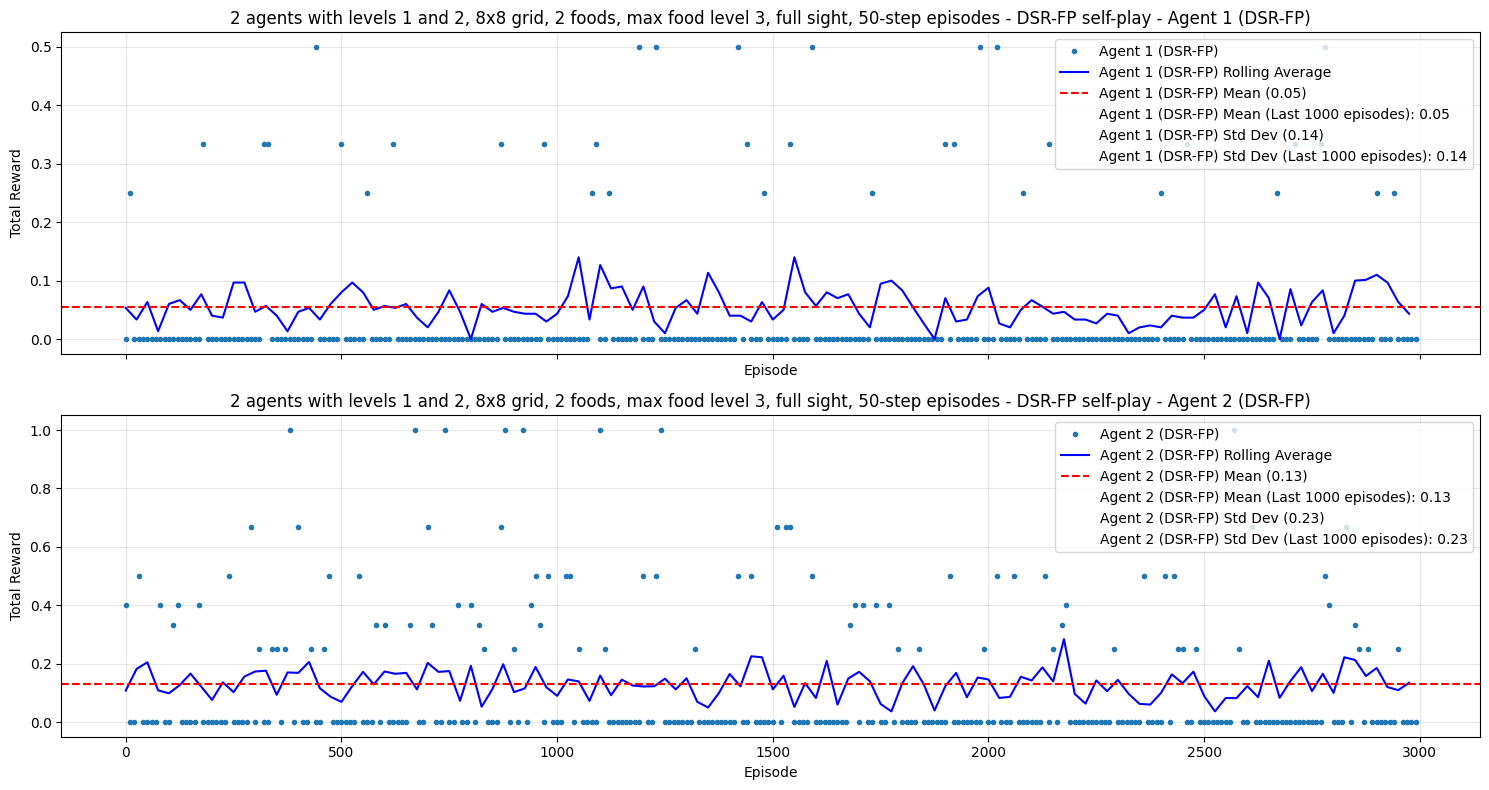


=== Running lbf_8x8_2p_2f_force_coop__dsr_fp ===
LBF DSR-FP | players=2 | eps0=0.5 | schedule=linear | seed=2030


lbf:dsr_fp_eps0.5_linear__lbf_8x8_2p_2f_force_coop__dsr_fp: 100%|██████████| 3000/3000 [21:19<00:00,  2.34it/s]



Reward Summary
Scenario           | Pair             | Agent            | Mean | Std  | Mean (Last 1000) | Std (Last 1000) | Episodes
-------------------+------------------+------------------+------+------+------------------+-----------------+---------
LBF 3-player basic | DSR-FP self-play | Agent 1 (DSR-FP) | 0.00 | 0.02 | 0.00             | 0.03            | 3000    
LBF 3-player basic | DSR-FP self-play | Agent 2 (DSR-FP) | 0.00 | 0.02 | 0.00             | 0.03            | 3000    


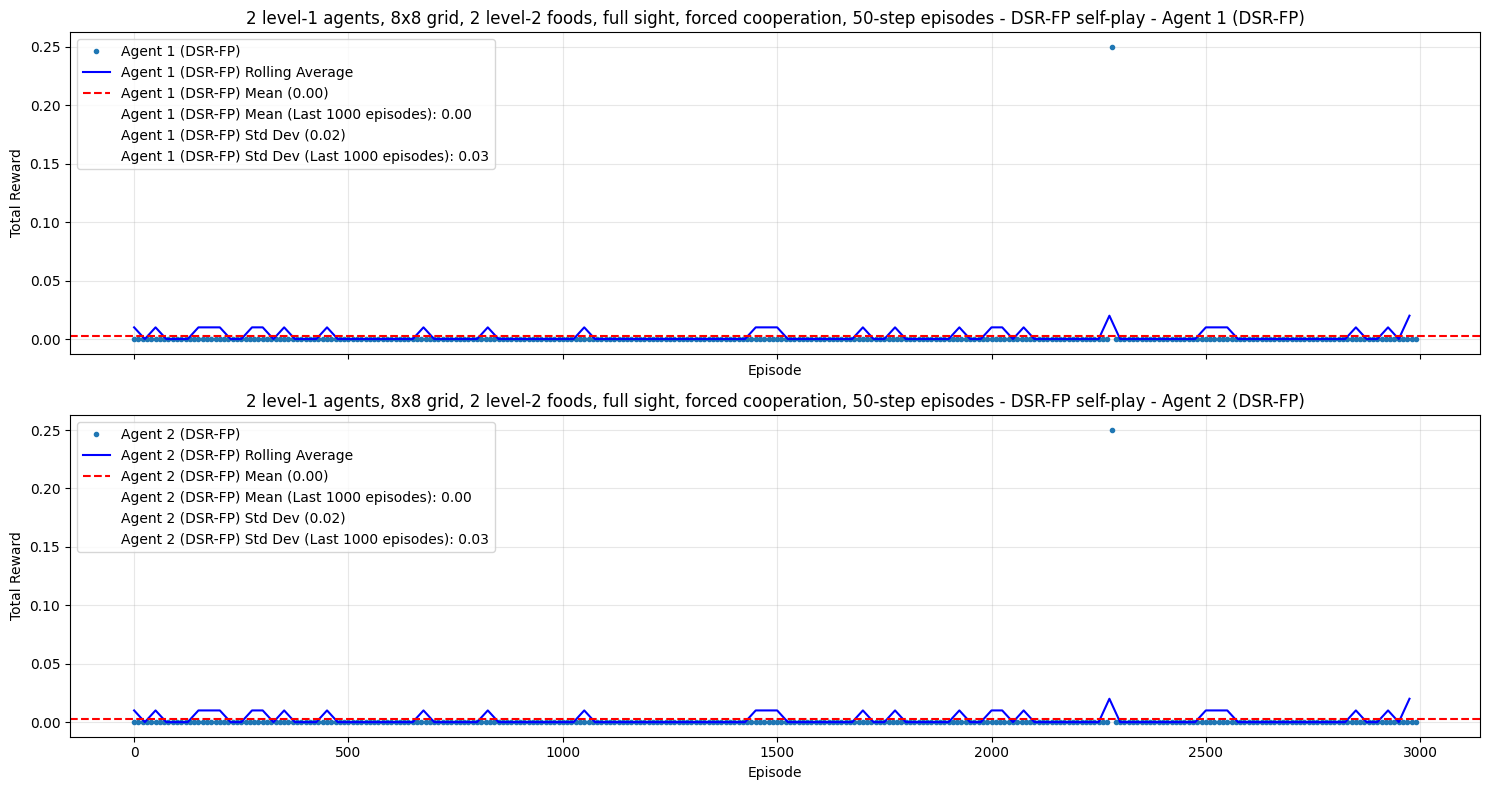


=== Running lbf_10x10_3p_8f_levels123__dsr_fp ===
LBF DSR-FP | players=3 | eps0=0.5 | schedule=linear | seed=2034


lbf:dsr_fp_eps0.5_linear__lbf_10x10_3p_8f_levels123__dsr_fp: 100%|██████████| 3000/3000 [1:21:34<00:00,  1.63s/it]



Reward Summary
Scenario           | Pair             | Agent            | Mean | Std  | Mean (Last 1000) | Std (Last 1000) | Episodes
-------------------+------------------+------------------+------+------+------------------+-----------------+---------
LBF 3-player basic | DSR-FP self-play | Agent 1 (DSR-FP) | 0.02 | 0.03 | 0.01             | 0.02            | 3000    
LBF 3-player basic | DSR-FP self-play | Agent 2 (DSR-FP) | 0.07 | 0.06 | 0.08             | 0.06            | 3000    
LBF 3-player basic | DSR-FP self-play | Agent 3 (DSR-FP) | 0.13 | 0.10 | 0.12             | 0.09            | 3000    


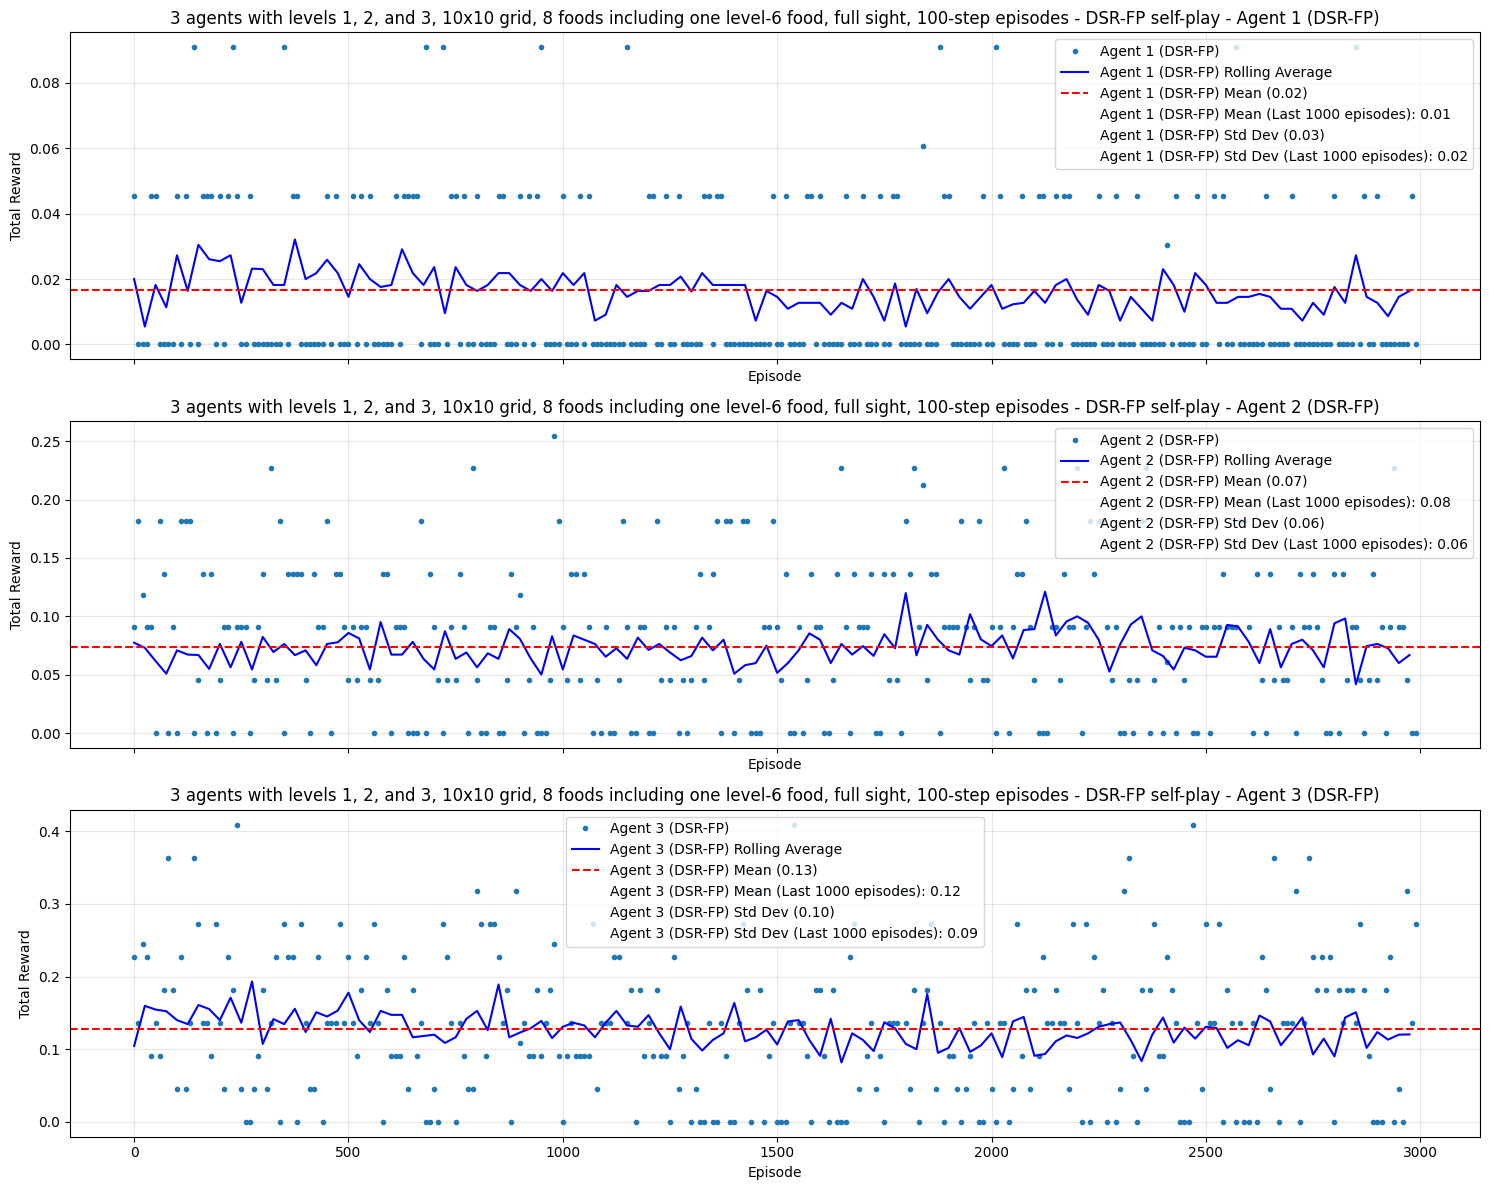

In [6]:
dsr_fp_stats = run_algorithm("dsr_fp")



=== Running lbf_8x8_2p_2f_levels12__sr_adidas ===


SR-ADIDAS:   3%|▎         | 100/3000 [00:22<11:51,  4.08it/s]

[ep   100] mean_sum_reward=   0.10 | tau=0.0061 | eps_rob=0.479 | eps_exp=0.947 | adi=0.00526 | buf=4982


SR-ADIDAS:   7%|▋         | 200/3000 [00:48<10:38,  4.39it/s]

[ep   200] mean_sum_reward=   0.09 | tau=0.0010 | eps_rob=0.458 | eps_exp=0.895 | adi=0.00355 | buf=5000


...

[ep  2800] mean_sum_reward=   0.00 | tau=0.0010 | eps_rob=0.000 | eps_exp=0.050 | adi=0.01075 | buf=5000


SR-ADIDAS:  97%|█████████▋| 2900/3000 [11:59<00:21,  4.67it/s]

[ep  2900] mean_sum_reward=   0.00 | tau=0.0010 | eps_rob=0.000 | eps_exp=0.050 | adi=0.01045 | buf=5000


SR-ADIDAS: 100%|██████████| 3000/3000 [12:19<00:00,  4.06it/s]


[ep  3000] mean_sum_reward=   0.00 | tau=0.0010 | eps_rob=0.000 | eps_exp=0.050 | adi=0.01304 | buf=5000


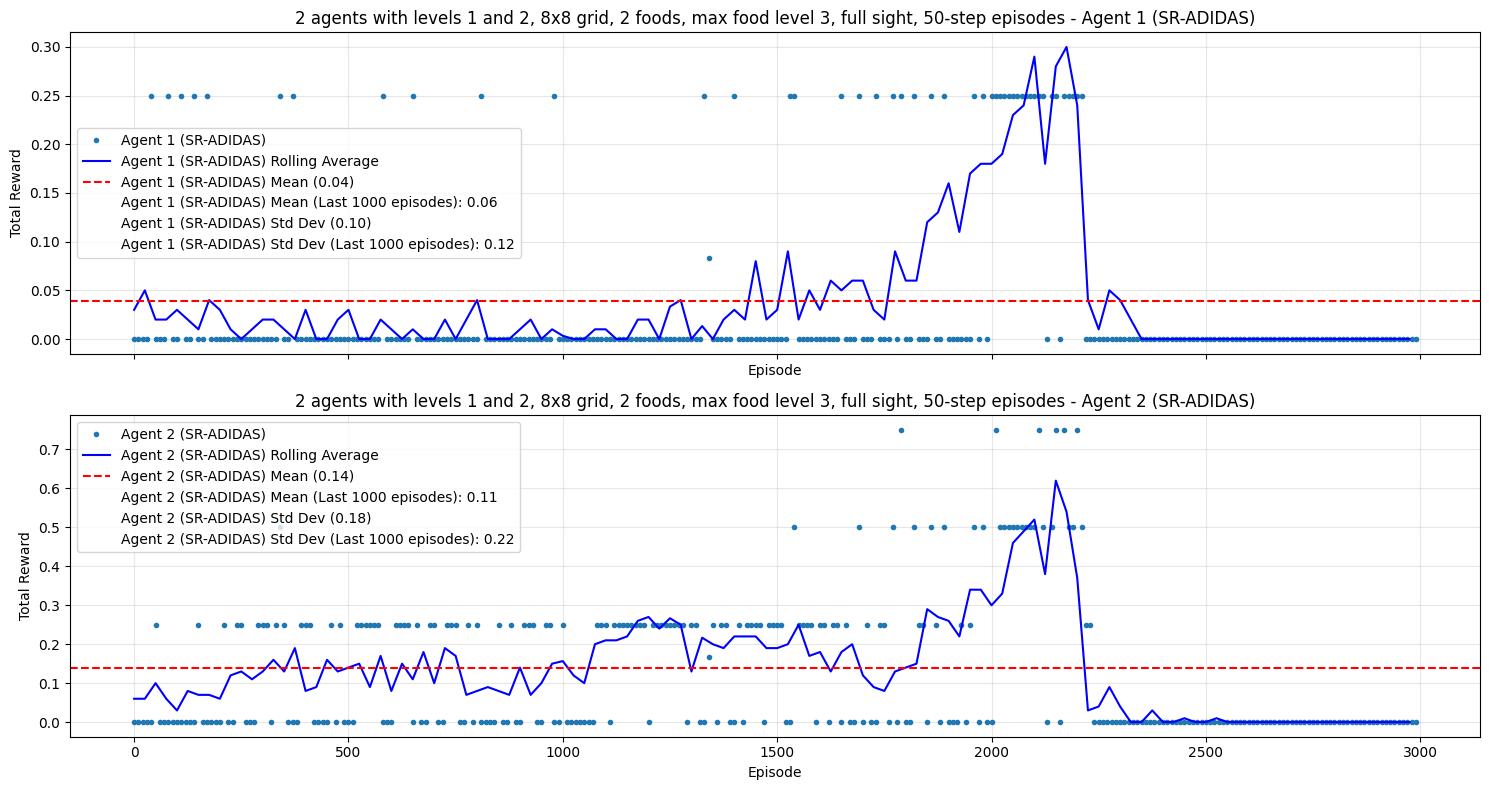


=== Running lbf_8x8_2p_2f_force_coop__sr_adidas ===


SR-ADIDAS:   3%|▎         | 100/3000 [00:23<11:26,  4.23it/s]

[ep   100] mean_sum_reward=   0.01 | tau=0.0010 | eps_rob=0.479 | eps_exp=0.947 | adi=0.00059 | buf=5000


SR-ADIDAS:   7%|▋         | 200/3000 [00:46<10:30,  4.44it/s]

[ep   200] mean_sum_reward=   0.00 | tau=0.0010 | eps_rob=0.458 | eps_exp=0.894 | adi=0.02083 | buf=5000


...

[ep  2800] mean_sum_reward=   0.00 | tau=0.0010 | eps_rob=0.000 | eps_exp=0.050 | adi=0.00189 | buf=5000


SR-ADIDAS:  97%|█████████▋| 2901/3000 [11:44<00:18,  5.28it/s]

[ep  2900] mean_sum_reward=   0.00 | tau=0.0010 | eps_rob=0.000 | eps_exp=0.050 | adi=0.00016 | buf=5000


SR-ADIDAS: 100%|██████████| 3000/3000 [12:02<00:00,  4.15it/s]


[ep  3000] mean_sum_reward=   0.00 | tau=0.0010 | eps_rob=0.000 | eps_exp=0.050 | adi=0.00082 | buf=5000


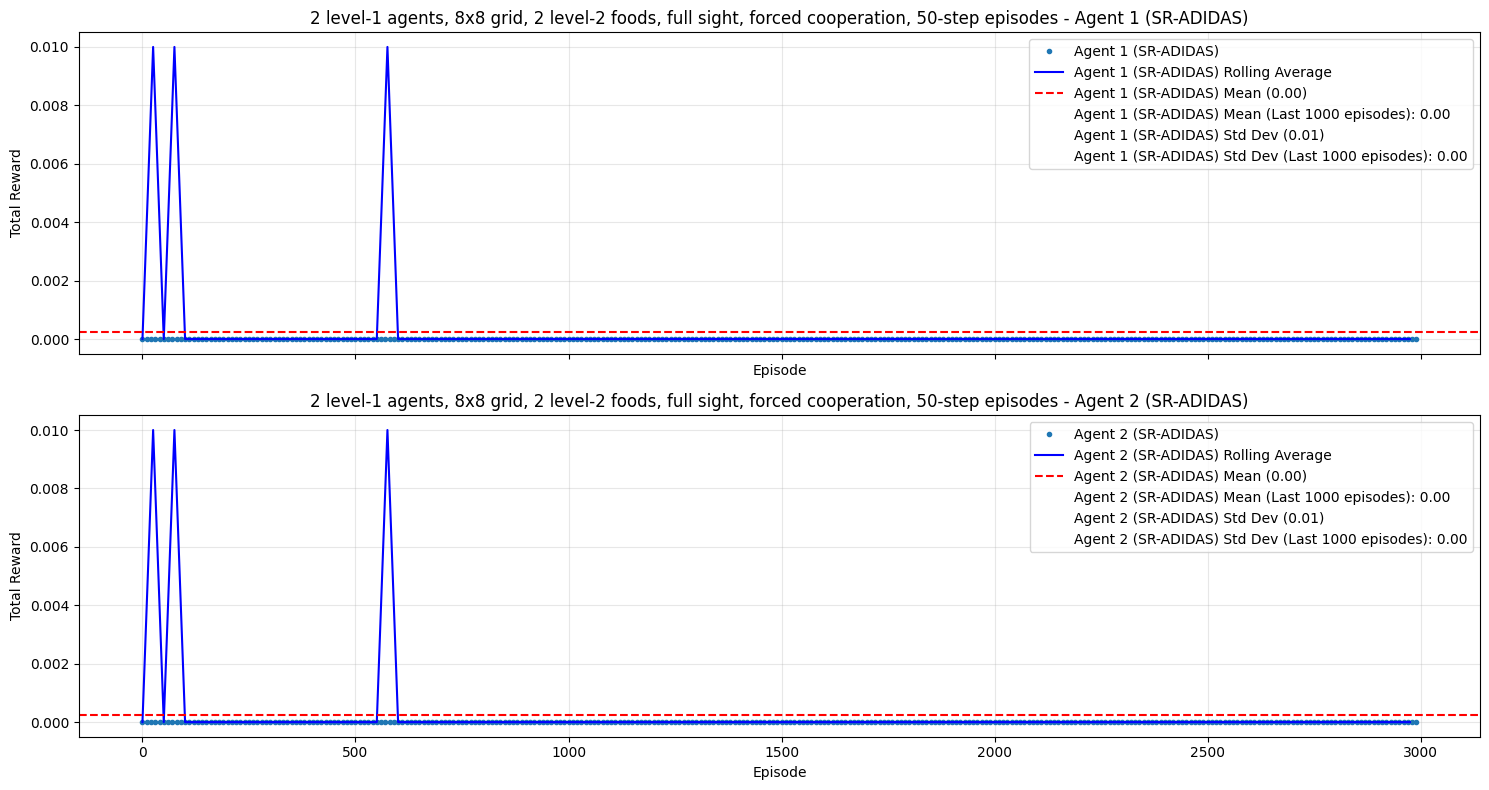


=== Running lbf_10x10_3p_8f_levels123__sr_adidas ===


SR-ADIDAS:   3%|▎         | 100/3000 [01:19<36:55,  1.31it/s]

[ep   100] mean_sum_reward=   0.24 | tau=0.0031 | eps_rob=0.479 | eps_exp=0.947 | adi=0.00205 | buf=5000


SR-ADIDAS:   7%|▋         | 200/3000 [02:41<37:05,  1.26it/s]

[ep   200] mean_sum_reward=   0.24 | tau=0.0010 | eps_rob=0.458 | eps_exp=0.894 | adi=0.00098 | buf=5000


...

[ep  2800] mean_sum_reward=   0.46 | tau=0.0010 | eps_rob=0.000 | eps_exp=0.050 | adi=0.00017 | buf=5000


SR-ADIDAS:  97%|█████████▋| 2900/3000 [35:54<00:50,  1.96it/s]

[ep  2900] mean_sum_reward=   0.45 | tau=0.0010 | eps_rob=0.000 | eps_exp=0.050 | adi=0.00013 | buf=5000


SR-ADIDAS: 100%|██████████| 3000/3000 [36:49<00:00,  1.36it/s]


[ep  3000] mean_sum_reward=   0.42 | tau=0.0010 | eps_rob=0.000 | eps_exp=0.050 | adi=0.00022 | buf=5000


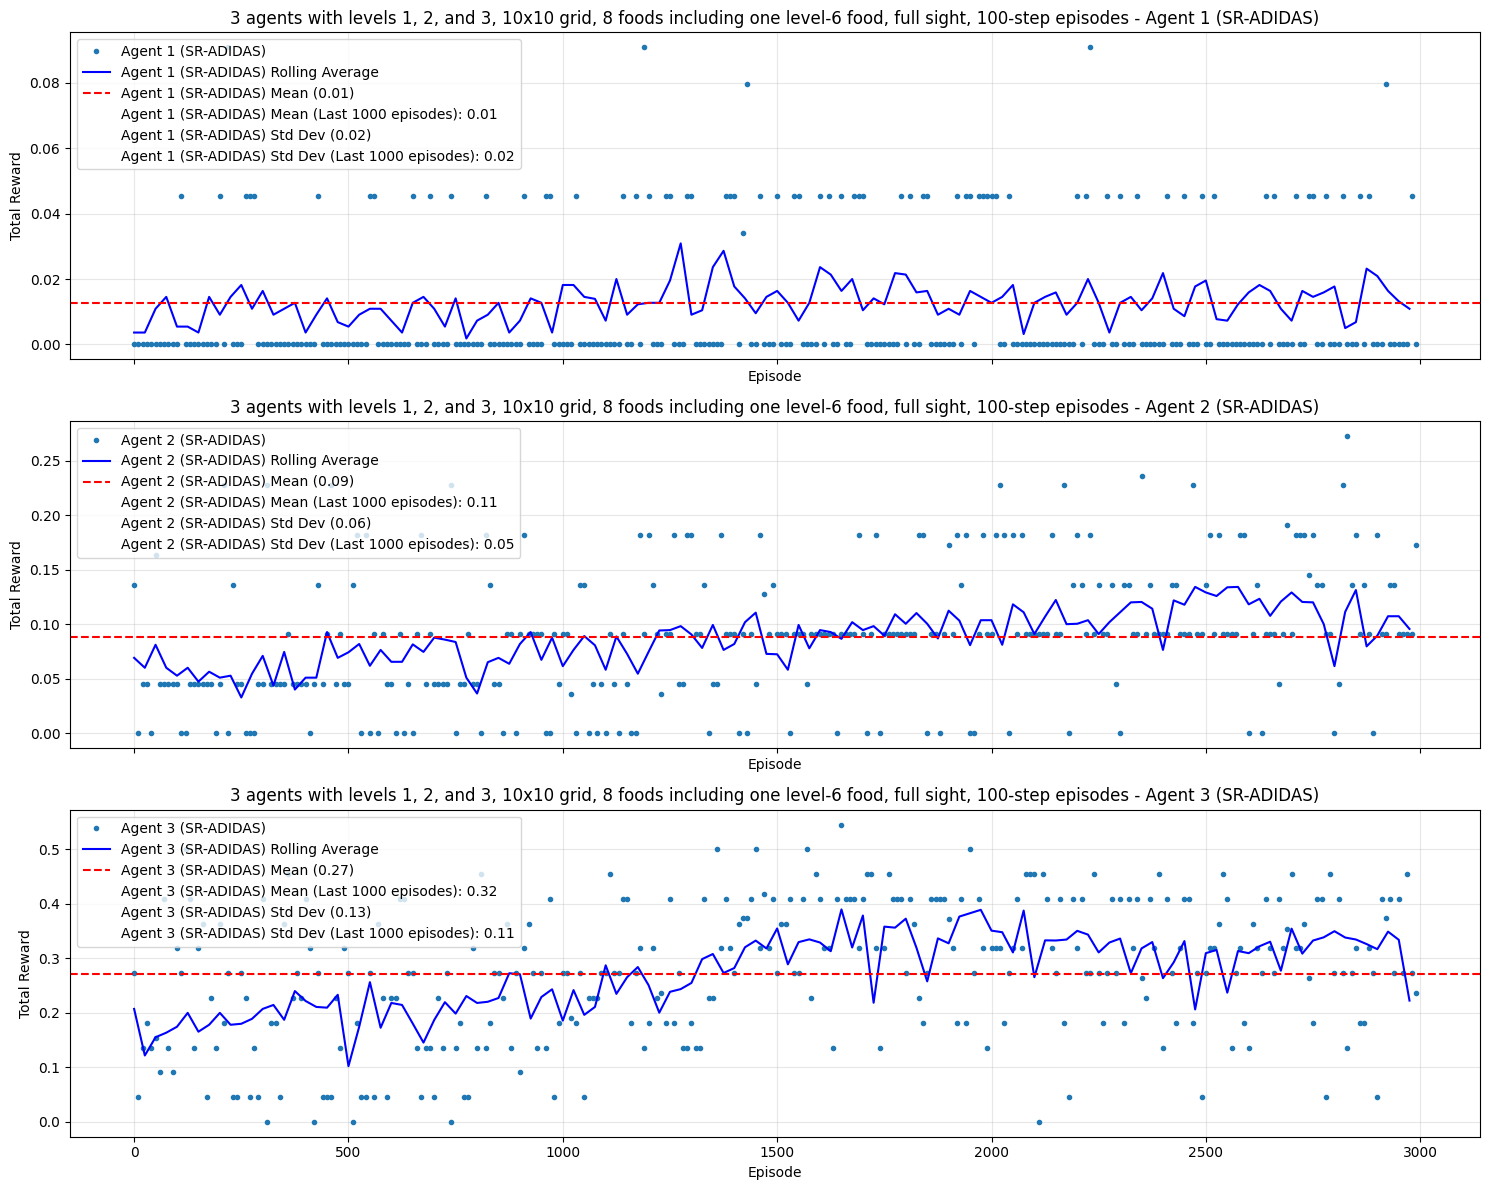

In [7]:
sr_adidas_stats = run_algorithm("sr_adidas")


In [ ]:
sorted(results.keys())


In [ ]:
import matplotlib.pyplot as plt


def rolling(values, window=20):
    values = np.asarray(values, dtype=float)
    if values.size == 0:
        return values
    window = max(1, min(window, values.size))
    return np.convolve(values, np.ones(window) / window, mode="valid")


ROLLING_WINDOW = 20
fig, axes = plt.subplots(len(SCENARIOS), 1, figsize=(12, 4 * len(SCENARIOS)), sharex=True)
if len(SCENARIOS) == 1:
    axes = [axes]

for ax, scenario in zip(axes, SCENARIOS):
    for variant in VARIANTS:
        key = _run_key(scenario, variant)
        stats = results.get(key)
        if not stats:
            continue
        joint_rewards = _joint_rewards(stats)
        if joint_rewards.size == 0:
            continue
        smoothed = rolling(joint_rewards, window=ROLLING_WINDOW)
        x = np.arange(smoothed.size) + min(ROLLING_WINDOW, joint_rewards.size)
        ax.plot(x, smoothed, label=variant["label"])
    ax.set_title(scenario["name"])
    ax.set_ylabel(f"Rolling joint reward ({ROLLING_WINDOW})")
    ax.grid(alpha=0.25)
    ax.legend()

axes[-1].set_xlabel("Completed episodes")
fig.suptitle("LBF robust algorithm comparison")
fig.tight_layout()
fig.savefig(OUTPUT_ROOT / "reward_curves.png")


In [ ]:
rows = []
for key, stats in sorted(results.items()):
    joint_rewards = _joint_rewards(stats)
    sre_timing = _sre_timing(stats)
    row = {
        "run_key": key,
        "scenario_key": stats.get("scenario_key"),
        "scenario_name": stats.get("scenario_name"),
        "variant": stats.get("ablation_variant"),
        "algorithm": stats.get("algorithm"),
        "status": stats.get("status", "ok"),
        "episodes": int(stats.get("n_episodes", joint_rewards.size)),
        "mean_joint_reward": None if joint_rewards.size == 0 else float(np.mean(joint_rewards)),
        "mean_last_20_joint_reward": None if joint_rewards.size == 0 else float(np.mean(joint_rewards[-20:])),
        "wall_clock_seconds": _wall_clock_seconds(stats),
        "sre_solves": sre_timing.get("count"),
        "mean_sre_solve_ms": None if sre_timing.get("mean_seconds") is None else 1000 * sre_timing["mean_seconds"],
        "stats_path": stats.get("stats_path"),
        "error_message": stats.get("error_message"),
        "skip_reason": stats.get("skip_reason"),
    }
    rows.append(row)
rows
